In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

import glob
from sklearn.metrics import precision_recall_curve, auc
from algs.cd_poly import CDPolynomial

In [38]:
n_eps = 1000
n_steps = 50

def process_data(file: str):
    npz = np.load(file)
    sa = npz["sa"]
    r = npz["rew"]
    param = npz["param"]
    fail = npz['fail']

    cols = [f"s{i}" for i in range(11)] + [f"a{i}" for i in range(3)]
    df = pd.DataFrame(
        data=sa,
        columns=cols
    )
    df['step'] = np.array([[i for i in range(n_steps)] for j in range(n_eps)]).flatten()
    df['t'] = df['step'] / n_steps # not in seconds
    df['ep'] = np.array([[i] * n_steps for i in range(n_eps)]).flatten()
    df['r'] = r
    df['damp'] = np.concatenate([np.full((n_steps,), param[i]) for i in range(n_eps)])

    df["cum_r"] = df.groupby('ep')['r'].cumsum()

    df['fail'] = (fail[df['ep']] > 0).astype(bool)
    df['fail_step'] = np.concatenate([[fail[i]] * n_steps for i in range(n_eps)])
    return df

def get_tsa(df):
    return df[['t'] + [f's{i}' for i in range(11)] + [f'a{i}' for i in range(3)]].to_numpy()

In [39]:
df_tr = process_data('hopper/train.npz')
df_te = process_data('hopper/test.npz')

In [41]:
# No encoding
p = CDPolynomial(get_tsa(df_tr[~df_tr['fail']]), degree=2, verbose=True, basis='cheb', eps=0)
df_tr['cd'] = np.log(p(get_tsa(df_tr)))
df_te['cd'] = np.log(p(get_tsa(df_te)))

Data monomials shape: torch.Size([39500, 136])
Moment matrix cond num: 8.968505e+10
Empirical mean of CD poly: 135.99998474121094


In [78]:
df_tr_succ = df_tr[~df_tr['fail']]
df_tr_fail = df_tr[df_tr['fail']]
df_te_succ = df_te[~df_te['fail']]
df_te_fail = df_te[df_te['fail']]

<Axes: xlabel='step'>

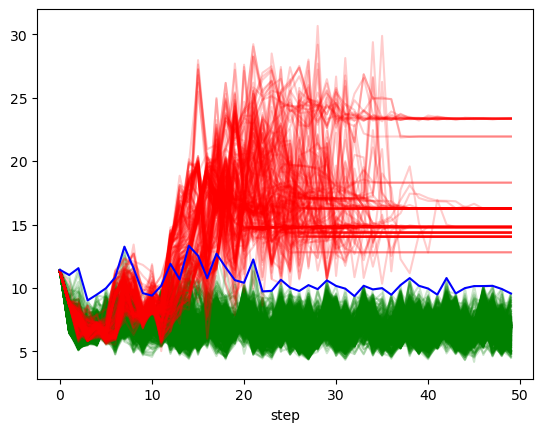

In [79]:
for i in df_te[~df_te['fail']]['ep'].unique():
    plt.plot(range(n_steps), df_te[~df_te['fail']][df_te[~df_te['fail']]['ep'] == i]['cd'], color='green', alpha=0.2)

for i in df_te[df_te['fail']]['ep'].unique():
    plt.plot(range(n_steps), df_te[df_te['fail']][df_te[df_te['fail']]['ep'] == i]['cd'], color='red', alpha=0.2)

df_te[~df_te['fail']].groupby('step')['cd'].quantile(1.).plot(color='blue')
#plt.gca().axhline(best_thresh)

#plt.xlim(0, 20)

In [80]:
y_true = df_te.groupby('ep').sample()['fail']
y_pred = df_te.groupby('ep')['cd'].max()

precision, recall, thresh = precision_recall_curve(y_true, y_pred)
auc(recall, precision)

1.0

In [81]:
best_thresh = df_tr_succ['cd'].max()
best_thresh

11.694986

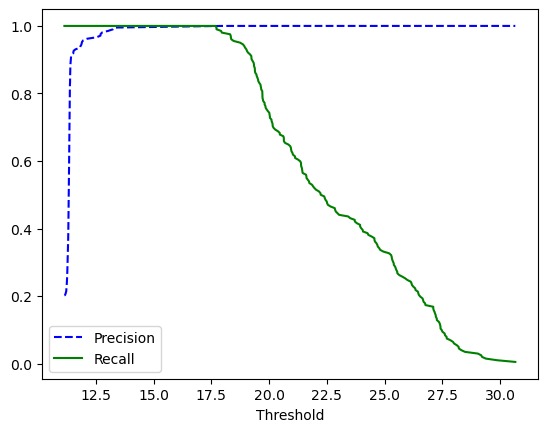

In [82]:
plt.plot(thresh, precision[:-1], "b--", label="Precision")
plt.plot(thresh, recall[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.legend()

In [83]:
df_te_fail_step = df_te_fail[['ep', 'fail_step']].drop_duplicates()['fail_step'].to_numpy()
df_te_fail_pred = df_te_fail[df_te_fail['cd'] >= best_thresh].groupby('ep').first()['step'].to_numpy()

assert len(df_te_fail_step) == len(df_te_fail_pred)

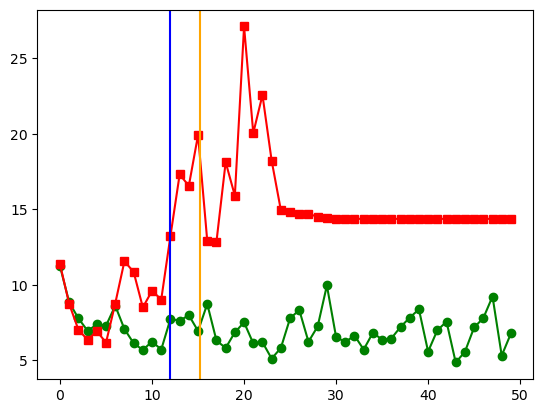

In [84]:
df = df_te_fail.pivot(index='ep', columns='step', values=['cd', 'r', 'fail_step']).sample(1)

plt.plot(df_te_succ.pivot(index='ep', columns='step', values='cd').sample(1).values.T, color='green', marker='o')
plt.plot(df['cd'].values.T, color='red', marker='s')

plt.axvline((df['cd'].values >= best_thresh).argmax(), color='blue')
plt.axvline(df['fail_step'].iloc[0,0], color='orange')

In [85]:
np.mean(df_te_fail_pred < df_te_fail_step)

1.0

In [86]:
ttd = (df_te_fail_step - df_te_fail_pred).mean()
ttd

4.275990099009901

## AE

In [54]:
from algs.pair_ae import PairAE
import lightning as L
from torch.utils.data import DataLoader

In [55]:
ds = df_tr.iloc[:,:14].to_numpy().astype(np.float32)  # NB: train on succ and fail?
dl = DataLoader(ds, batch_size=128)

In [61]:
pae = PairAE(state_dim=11, action_dim=3, latent_dim=5, lr=1e-3)
trainer = L.Trainer(max_epochs=10)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [62]:
trainer.fit(pae, dl)


  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | encoder | Sequential | 3.2 K  | train
1 | decoder | Sequential | 3.2 K  | train
-----------------------------------------------
6.4 K     Trainable params
0         Non-trainable params
6.4 K     Total params
0.026     Total estimated model params size (MB)
13        Modules in train mode
0         Modules in eval mode


/Users/ljn/anaconda3/envs/cd_project/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 9: 100%|██████████| 391/391 [00:02<00:00, 158.48it/s, v_num=1, loss=0.0329]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 391/391 [00:02<00:00, 157.65it/s, v_num=1, loss=0.0329]


In [77]:
# with encoding
z = pae.encode(torch.Tensor(df_tr_succ.iloc[:,:14].to_numpy()))
p = CDPolynomial(z.detach().numpy(), degree=6, verbose=True, basis='cheb', eps=0)
df_tr['cd'] = np.log(p(pae.encode(torch.Tensor(df_tr.iloc[:,:14].to_numpy()))))
df_te['cd'] = np.log(p(pae.encode(torch.Tensor(df_te.iloc[:,:14].to_numpy()))))

Data monomials shape: torch.Size([39500, 462])
Moment matrix cond num: 1.857512e+13
Empirical mean of CD poly: 462.00054931640625


## Random proj

In [ ]:
from sklearn.random_projection import GaussianRandomProjection

In [ ]:
pr = GaussianRandomProjection(n_components=5)

In [ ]:
p = CDPolynomial(pr.fit_transform(df_tr_succ.iloc[:,:14]), degree=6, verbose=True, basis='cheb', eps=0)
df_tr['cd'] = np.log(p(pr.transform(df_tr.iloc[:,:14])))
df_te['cd'] = np.log(p(pr.transform(df_te.iloc[:,:14])))

Data monomials shape: torch.Size([39600, 462])
Moment matrix cond num: 5.105870e+18
Empirical mean of CD poly: 462.4716796875
